In [ ]:
import sys
import os
from pathlib import Path
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb

sys.path.insert(0, str(Path(os.getcwd()).parent))
os.chdir(Path(os.getcwd()).parent)

In [ ]:
from src.data_preparation import TennisMatchDataset, TRAIN_YEARS, HOLDOUT_YEAR
from src.distributions import BayesianBetaPosterior
from src.evaluation import simulate_match_stats, STAT_DIFF_COLS
from src.models import XGBoostTennisModel, RandomForestTennisModel, MLPTennisModel
from main import DATA_RAW_DIR, DATA_PROCESSED_DIR

## Variable Importance Check

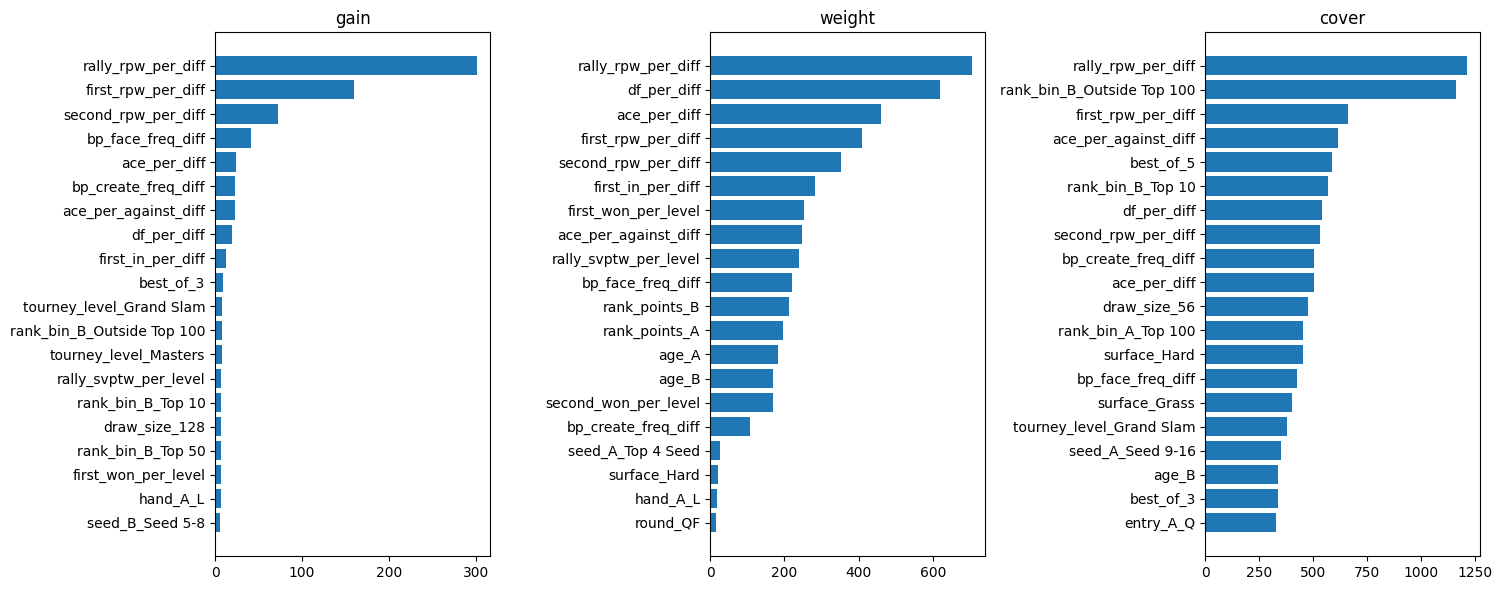

shape: (20, 6)
┌─────────────────────┬────────┬────────────┬─────────────┬───────────────┬───────────────┐
│ feature             ┆ weight ┆ gain       ┆ cover       ┆ total_gain    ┆ total_cover   │
│ ---                 ┆ ---    ┆ ---        ┆ ---         ┆ ---           ┆ ---           │
│ str                 ┆ f64    ┆ f64        ┆ f64         ┆ f64           ┆ f64           │
╞═════════════════════╪════════╪════════════╪═════════════╪═══════════════╪═══════════════╡
│ rally_rpw_per_diff  ┆ 705.0  ┆ 301.503265 ┆ 1210.878662 ┆ 212559.796875 ┆ 853669.4375   │
│ first_rpw_per_diff  ┆ 409.0  ┆ 159.733398 ┆ 662.495422  ┆ 65330.957031  ┆ 270960.625    │
│ second_rpw_per_diff ┆ 353.0  ┆ 72.032715  ┆ 529.435181  ┆ 25427.548828  ┆ 186890.609375 │
│ bp_face_freq_diff   ┆ 219.0  ┆ 41.214096  ┆ 423.354095  ┆ 9025.886719   ┆ 92714.546875  │
│ ace_per_diff        ┆ 460.0  ┆ 23.640314  ┆ 505.311584  ┆ 10874.544922  ┆ 232443.328125 │
│ …                   ┆ …      ┆ …          ┆ …           ┆ …    

In [2]:
model_path = "models/xgboost.ubj"
top_n = 20

booster = xgb.Booster()
booster.load_model(model_path)
feature_names = booster.feature_names

types = ["weight", "gain", "cover", "total_gain", "total_cover"]
scores = {t: booster.get_score(importance_type=t) for t in types}

idx = feature_names or sorted({k for s in scores.values() for k in s})
data = {"feature": idx}
for t in types:
    data[t] = [scores[t].get(f, 0.0) for f in idx]
df = pl.DataFrame(data)
df = df.sort("gain", descending=True)

metrics = ["gain", "weight", "cover"] + (
    ["shap_mean_abs"] if "shap_mean_abs" in df.columns else []
)
fig, axes = plt.subplots(
    1, len(metrics), figsize=(5 * len(metrics), max(4, top_n * 0.3))
)
axes = np.atleast_1d(axes)
for ax, m in zip(axes, metrics):
    top = df.sort(m, descending=True).head(top_n).reverse()
    ax.barh(top["feature"].to_list(), top[m].to_list())
    ax.set_title(m)
plt.tight_layout()
plt.show()

print(df.head(20))

In [3]:
xgb_path = "models/xgboost.ubj"
rf_path = "models/random_forest.joblib"
mlp_path = "models/mlp.pt"

dataset = TennisMatchDataset(
    years=list(TRAIN_YEARS) + [HOLDOUT_YEAR],
    raw_cache_dir=DATA_RAW_DIR,
    processed_cache_dir=DATA_PROCESSED_DIR,
)
dataset.process()
posterior = BayesianBetaPosterior(
    decay=1, prior_year=2003, prior_concentration=900, sample_concentration=150
)
posterior.fit(dataset.get_pm_data())
xgb_model = XGBoostTennisModel().load(xgb_path)
rf_model = RandomForestTennisModel().load(rf_path)
mlp_model = MLPTennisModel().load(mlp_path)

Processing data...
Loading data...
Transforming to player matches...
Limiting player matches...
Adding basic features...
Adding opponent features...
Deriving match-diff format...
Computing empirical Bayes priors...
Computing rolling posteriors...


## Depicting Posterior Over Time

In [32]:
sample_concentration = 150

posterior_diagnostic_df = (
    posterior.posterior_df.filter(
        pl.col("name") == "Rafael Nadal",
        pl.col("surface") == "Clay",
        pl.col("opp_rank_bin") == "Top 10",
        pl.col("stat") == "rally_rpw_per",
    )
    .sort("match_id")
    .with_columns(
        sample_alpha=pl.col("alpha")
        * pl.min_horizontal(
            1, sample_concentration / (pl.col("alpha") + pl.col("beta"))
        ),
        sample_beta=pl.col("beta")
        * pl.min_horizontal(
            1, sample_concentration / (pl.col("alpha") + pl.col("beta"))
        ),
    )
    .join(
        dataset._original_df.with_columns(
            match_id=pl.concat_str(
                pl.col("tourney_date"),
                pl.col("winner_id"),
                pl.col("loser_id"),
                separator="-",
            )
        ).select(
            "match_id",
            "tourney_name",
            "tourney_date",
            "winner_name",
            "loser_name",
            "winner_rank",
            "loser_rank",
        ),
        on="match_id",
    )
    .join(
        dataset.player_matches_wfeat.select("match_id", "match_order").unique(),
        on="match_id",
    )
    .sort("match_order")
)

comparing_stats = (
    dataset.get_pm_data()
    .filter(pl.col("opp_rank_bin") == "Top 10", pl.col("surface") == "Clay")[
        "rally_rpw_per"
    ]
    .to_numpy()
)

In [33]:
from scipy.stats import beta

x_values = np.arange(0.01, 1.00001, 0.01)
pdf_values = beta.pdf(
    np.repeat(x_values, 119).reshape((100, 119)),
    a=posterior_diagnostic_df["sample_alpha"].to_numpy(),
    b=posterior_diagnostic_df["sample_beta"].to_numpy(),
)

In [34]:
import matplotlib.animation as animation
from IPython.display import HTML

fig, ax = plt.subplots(figsize=(8, 4))
(line,) = ax.plot(x_values, pdf_values[:, 0])
ax.set_ylim(0, pdf_values.max() * 1.1)
initial_mean = posterior_diagnostic_df["sample_alpha"].to_numpy()[0] / (
    posterior_diagnostic_df["sample_alpha"].to_numpy()[0]
    + posterior_diagnostic_df["sample_beta"].to_numpy()[0]
)
vline = ax.axvline(x=initial_mean, color="red", label="Mean for Rafa")
title = ax.set_title("Posterior after 1 match")


def update(i):
    line.set_ydata(pdf_values[:, i])
    title.set_text(
        f"Rafael Nadal Return Points Won % on Clay\nPosterior after {i + 1} match{'es' if i > 0 else ''}"
    )
    alpha = posterior_diagnostic_df["sample_alpha"].to_numpy()[i]
    beta = posterior_diagnostic_df["sample_beta"].to_numpy()[i]
    vline.set_xdata([alpha / (alpha + beta)])
    return line, title, vline


ax.hist(comparing_stats, density=True, bins=30, label="Population Distribution")
ax.legend()
ani = animation.FuncAnimation(fig, update, frames=119, interval=100, blit=True)
plt.close()
HTML(ani.to_jshtml())

## Accuracy Breakdown

In [18]:
n_sims_list = list(range(50, 1001, 50))
holdout_data = dataset.get_holdout_data()
player_matches_wfeat = dataset.get_pm_data()
max_sims = max(n_sims_list)
simulated_all = simulate_match_stats(
    posterior, holdout_data, player_matches_wfeat, max_sims
)
results = []
fixed_cols = [
    c
    for c in holdout_data.columns
    if c not in STAT_DIFF_COLS + ["player_a_won", "match_id", "year"]
]
fixed_feat_df = holdout_data.select(["match_id"] + fixed_cols)
merged = simulated_all.join(fixed_feat_df, on="match_id", how="left")
feature_cols = list(dataset.X_train.columns)
continuous_cols = dataset.continuous_feature_cols
scaler = dataset.scaler
available_cols = [c for c in feature_cols if c in merged.columns]
X_df = merged.select(available_cols)

if scaler is not None and continuous_cols is not None:
    scaled = scaler.transform(X_df.select(continuous_cols).to_numpy())
    X_df = X_df.with_columns(pl.from_numpy(scaled, schema=continuous_cols))

X = X_df.to_numpy().astype(np.float32)
proba_xgb = xgb_model.predict_proba(X)
proba_rf = rf_model.predict_proba(X)
proba_mlp = mlp_model.predict_proba(X)

wp_match_id_lookup = (
    merged.with_columns(
        xgb_pred_prob=proba_xgb[:, 1],
        rf_pred_prob=proba_rf[:, 1],
        mlp_pred_prob=proba_mlp[:, 1],
    )
    .group_by("match_id")
    .agg(pl.col("^.*_pred_prob$").mean())
)

In [19]:
player_match_count_lookup = (
    player_matches_wfeat.sort("name", "match_order")
    .with_columns(
        total_matches_played_prior=pl.col("match_id")
        .cum_count()
        .over("name", "surface", "opp_rank_bin")
        - 1
    )
    .select(
        "match_id",
        "id",
        "name",
        "surface",
        "opp_rank_bin",
        "total_matches_played_prior",
    )
    .group_by("match_id")
    .agg(
        pl.col("total_matches_played_prior")
        .filter(pl.col("name") == pl.col("name").min())
        .min()
        .alias("player_a_minprior"),
        pl.col("total_matches_played_prior")
        .filter(pl.col("name") == pl.col("name").max())
        .min()
        .alias("player_b_minprior"),
    )
)

In [20]:
analysis_df = (
    player_matches_wfeat.group_by("match_id", "surface", "tourney_name", "round")
    .agg(
        pl.col("name").min().alias("player_a"),
        pl.col("name").max().alias("player_b"),
        pl.col("rank")
        .filter(pl.col("name") == pl.col("name").min())
        .alias("rank_player_a")
        .min(),
        pl.col("rank")
        .filter(pl.col("name") == pl.col("name").max())
        .alias("rank_player_b")
        .min(),
        pl.col("result")
        .filter(pl.col("name") == pl.col("name").min())
        .min()
        .alias("true_result"),
    )
    .join(wp_match_id_lookup, on="match_id")
    .with_columns(true_result=(pl.col("true_result") == "winner").cast(pl.Float32))
    .join(player_match_count_lookup, on="match_id")
    .with_columns(
        pl.col("^.*_pred_prob$").round().name.prefix("rounded_"),
        (pl.col("rank_player_a") < pl.col("rank_player_b"))
        .cast(pl.Float64)
        .alias("rounded_rank_prob"),
    )
    .with_columns(
        pl.col("^rounded.*$")
        .eq(pl.col("true_result"))
        .cast(pl.Float64)
        .name.prefix("acc_")
    )
)

In [21]:
# baseline accuracy
analysis_df.select(pl.col("^acc_.*$").mean())

acc_rounded_xgb_pred_prob,acc_rounded_rf_pred_prob,acc_rounded_mlp_pred_prob,acc_rounded_rank_prob
f64,f64,f64,f64
0.638953,0.642802,0.638183,0.633949


### Surface Analysis

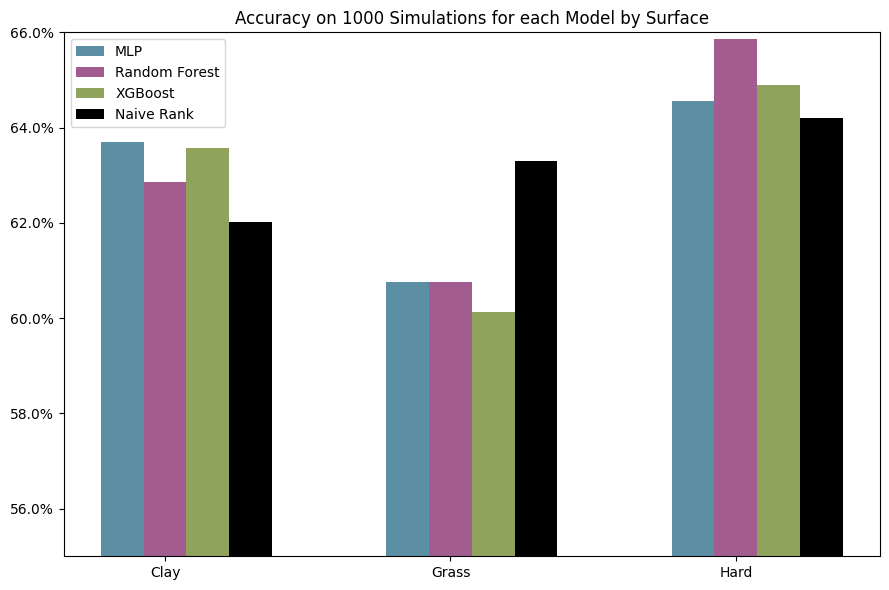

In [22]:
from matplotlib.ticker import PercentFormatter

model_colors = {
    "MLP": "#5C8FA3",
    "Random Forest": "#A35C8F",
    "XGBoost": "#8FA35C",
    "Naive Rank": "black",
}
surface_summary = (
    analysis_df.group_by("surface")
    .agg(pl.col("^acc_.*$").mean())
    .sort("surface")
    .unpivot(index="surface")
    .with_columns(
        model_label=pl.when(pl.col("variable").str.contains("xgb"))
        .then(pl.lit("XGBoost"))
        .when(pl.col("variable").str.contains("mlp"))
        .then(pl.lit("MLP"))
        .when(pl.col("variable").str.contains("rf"))
        .then(pl.lit("Random Forest"))
        .otherwise(pl.lit("Naive Rank"))
    )
)
fig, ax = plt.subplots(1, 1, figsize=(9, 6))

x_loc = np.arange(3)
col_width = 0.15

# plot three models
for index, (model, color) in enumerate(model_colors.items()):
    chart_data = surface_summary.filter(pl.col("model_label") == model).sort("surface")
    ax.bar(
        x_loc + col_width * index,
        chart_data["value"],
        color=color,
        width=col_width,
        label=model,
    )
ax.set_xticks(ticks=x_loc + col_width, labels=["Clay", "Grass", "Hard"])
ax.set_ylim((0.55, 0.66))
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))

ax.set_title("Accuracy on 1000 Simulations for each Model by Surface")
ax.legend()
fig.tight_layout()

### Sample Size Analysis

In [23]:
sample_size_df = (
    analysis_df.with_columns(
        min_matches_both_played=pl.min_horizontal(
            pl.col("player_a_minprior"), pl.col("player_b_minprior")
        )
    )
    .group_by("min_matches_both_played")
    .agg(pl.col("^acc_.*$").sum(), pl.len().alias("total_matches"))
    .sort("min_matches_both_played", descending=True)
    .with_columns(pl.col("^acc_.*$").cum_sum() / pl.col("total_matches").cum_sum())
    .unpivot(index=["min_matches_both_played", "total_matches"])
    .with_columns(
        model_label=pl.when(pl.col("variable").str.contains("xgb"))
        .then(pl.lit("XGBoost"))
        .when(pl.col("variable").str.contains("mlp"))
        .then(pl.lit("MLP"))
        .when(pl.col("variable").str.contains("rf"))
        .then(pl.lit("Random Forest"))
        .otherwise(pl.lit("Naive Rank"))
    )
)

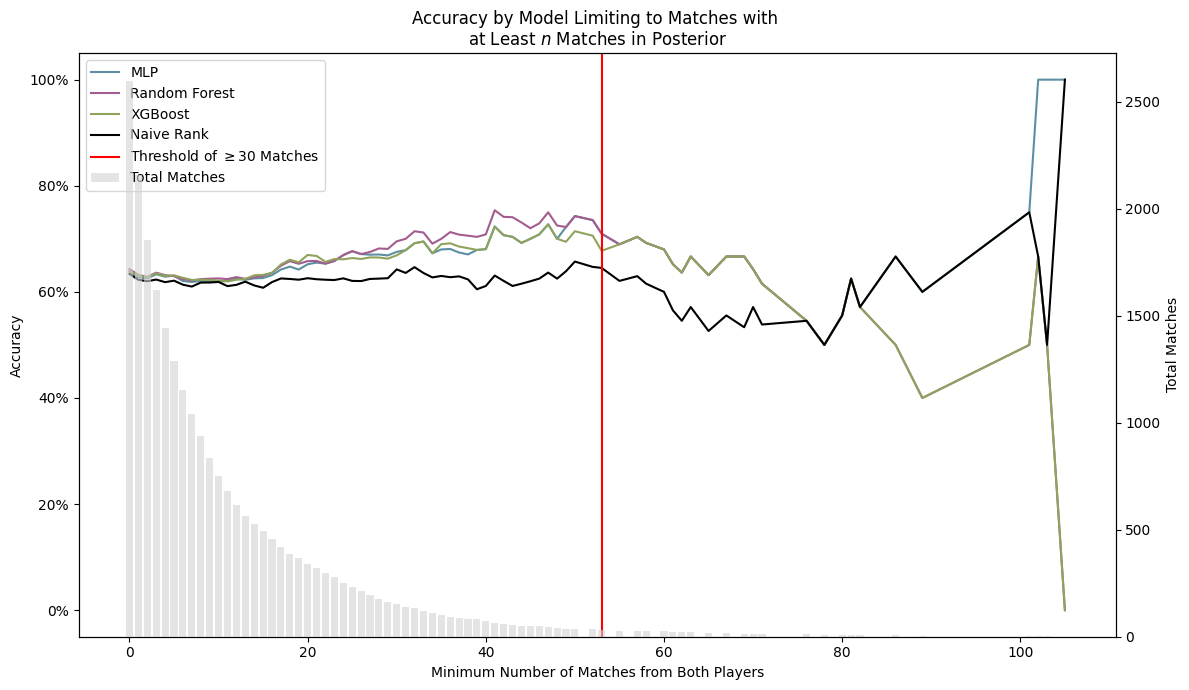

In [24]:
fig, ax = plt.subplots(1, 1, figsize=(12, 7))

for index, (model, color) in enumerate(model_colors.items()):
    chart_data = sample_size_df.filter(pl.col("model_label") == model).sort(
        "min_matches_both_played"
    )
    ax.plot(
        chart_data["min_matches_both_played"],
        chart_data["value"],
        color=color,
        label=model,
    )
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))
ax.set_title(
    "Accuracy by Model Limiting to Matches with \nat Least $n$ Matches in Posterior"
)
ax.set_xlabel("Minimum Number of Matches from Both Players")
ax.set_ylabel("Accuracy")

ax2 = ax.twinx()
match_counts = (
    sample_size_df.filter(pl.col("model_label") == "XGBoost")
    .sort("min_matches_both_played", descending=True)
    .with_columns(cumulative_matches=pl.col("total_matches").cum_sum())
)
ax2.bar(
    match_counts["min_matches_both_played"],
    match_counts["cumulative_matches"],
    color="lightgray",
    alpha=0.6,
    label="Total Matches",
)
ax2.set_ylabel("Total Matches")

ax.axvline(x=53, color="red", label="Threshold of $\\geq 30$ Matches")

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2)

fig.tight_layout()